# TomatoWUR — minimal skeletonisation & trait-evaluation demonstration

**Paper:** van Marrewijk et al., *TomatoWUR: An annotated dataset of tomato plants to quantitatively evaluate segmentation, skeletonisation, and plant-trait extraction algorithms for 3D plant phenotyping*, Data in Brief 61:111852 (2025). [https://doi.org/10.1016/j.dib.2025.111852](https://doi.org/10.1016/j.dib.2025.111852)

**Code (author):** [https://github.com/WUR-ABE/TomatoWUR](https://github.com/WUR-ABE/TomatoWUR) — release tag `original_tomatowur_paper`, commit `8810c57d7d89a7ed78d7dde1c2336ef8748ceaf0` (GPL-3.0).
**Data (author):** 4TU.ResearchData DOI `10.4121/e2c59841-4653-45de-a75e-4994b2766a2f`, **version 2** (paper-era upload), CC BY-SA 4.0.

**Scope (partial demonstration):** run the authors' Xu point-cloud skeletonisation on **one** released test-split tomato plant, then evaluate predicted plant nodes, edges and traits (internode length, phyllotactic angle, leaf angle) against the released ground-truth skeleton (which carries the manual measurements) with the authors' own evaluation code. This is **not** a reproduction of any dataset-level benchmark; it exercises the released pipeline on a single example.

**実行内容 (日本語):** 論文公開データセット（4TU v2）のテスト分割からトマト1株の点群を選び、著者らのXu法による骨格化を実行します。その結果を、手動計測値を含む公開 ground-truth 骨格と、著者提供の評価コード（2 cm ノード一致閾値、次数別 precision/recall、Chamfer距離、エッジTP/FP/FN、形質のMAE/MAPE）で比較します。データセット全体のベンチマーク再現ではありません。

**Runtime:** CPU only (classical point-cloud processing; no GPU code path). **Run all** expects ~10–25 min end-to-end, dominated by downloads (~30 MB via selective ZIP range extraction, or the full 3.4 GB archive if the server rejects range requests) and the Xu skeletonisation.


## 1. Environment check

This notebook needs no GPU. We first report the Colab runtime we got.

**日本語:** GPUは不要です。まず割り当てられたランタイム環境を確認します。

In [ ]:
import platform, sys
print("Python:", sys.version)
print("Platform:", platform.platform())

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.39


## 2. Dependencies

The authors' pinned tag code needs (requirements.txt of the tag): numpy, pandas, scipy,
scikit-learn, matplotlib, networkx, tqdm, requests (all preinstalled on Colab) plus
`open3d`, `opencv-python`, `polyscope`, `natsort`, `omegaconf`. The authors' later
pyproject pins `open3d==0.19.0`, which has no wheel for Colab's current Python (3.13);
we install `open3d==0.20.0`, the closest available release.

**日本語:** 著者コードが要求するパッケージのうちColabに無いものをインストールします。著者指定のopen3d 0.19.0はPython 3.13用wheelが無いため、最新の0.20.0を使用します。

In [ ]:
%pip install -q open3d==0.20.0 opencv-python polyscope natsort omegaconf
import open3d, cv2, polyscope, natsort, omegaconf  # noqa: F401 - verify imports
print("open3d", open3d.__version__)

open3d 0.20.0


## 3. Fetch the pinned author code

We download only the source files actually needed, from the pinned tag commit `8810c57d7d89a7ed78d7dde1c2336ef8748ceaf0`,
and verify each file against its git blob SHA-1 (exact pinned revision, no mutable branch).

**日本語:** 著者リポジトリの固定コミットから、必要なソースファイルのみをダウンロードし、git blob SHA-1で完全性を検証します。

In [ ]:
import hashlib, pathlib, requests, sys

COMMIT = "8810c57d7d89a7ed78d7dde1c2336ef8748ceaf0"
BASE = "https://raw.githubusercontent.com/WUR-ABE/TomatoWUR/" + COMMIT + "/"

# path -> (git blob sha1, size in bytes), from the tag tree via the GitHub API
FILES = {
    "scripts/__init__.py": ("e69de29bb2d1d6434b8b29ae775ad8c2e48c5391", 0),
    "scripts/calculate_angles.py": ("cc0cd927d43043ee1cc880b6c805cb3e5feb6eb1", 7715),
    "scripts/calculate_metrics.py": ("5f8922d829f1956abcb332906423ed7195f93fb9", 8887),
    "scripts/evaluate_skeletons.py": ("76b64e4ae2dce65e987a0debd88a71b01a783457", 27499),
    "scripts/skeleton_graph.py": ("d683116745ed4fb4c8c0b50693a8116e5866391f", 31291),
    "scripts/utils_data.py": ("0d593f54db51bc75ce8de262256c03010351575c", 5460),
    "scripts/utils_skeletonisation.py": ("fc61c5b1dbeffd3246f04baa385613c68262352e", 17628),
    "scripts/visualize_examples.py": ("0f37cef518a8beff09a6421b0630159c57003095", 15259),
    "skeletonisation_methods/__init__.py": ("e69de29bb2d1d6434b8b29ae775ad8c2e48c5391", 0),
    "skeletonisation_methods/plantscan3d/__init__.py": ("e69de29bb2d1d6434b8b29ae775ad8c2e48c5391", 0),
    "skeletonisation_methods/plantscan3d/algo.py": ("63644d046b6fc607ad6c307bcc6ea05ff32fc2c4", 14513),
    "skeletonisation_methods/plantscan3d/io.py": ("a05c49c82581847d6ca7c9dfc739bbe9268d7aa2", 56065),
    "skeletonisation_methods/plantscan3d/mtg.py": ("bf044ac281a1aa4df43af115d91f299cf5df1bbf", 86955),
    "skeletonisation_methods/plantscan3d/mtgmanip.py": ("f301a6419a9f5d66881013b6839c910764a7281e", 11990),
    "skeletonisation_methods/plantscan3d/traversal.py": ("50dbefc33535343b7a9b1316289edb1d5249e19f", 17630),
    "skeletonisation_methods/plantscan3d/tree.py": ("f9d31678f9a3252e5ab12a548d4b0809e84f2839", 22686),
    "skeletonisation_methods/plantscan3d/xu.py": ("9f06feac99e14c3dbc781da9c1f644cc8fea2afa", 20506),
}

def blob_sha1(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

CODE_ROOT = pathlib.Path("/content/tomatowur_code")
for rel, (sha, size) in FILES.items():
    r = requests.get(BASE + rel, timeout=120)
    r.raise_for_status()
    data = r.content
    assert len(data) == size, (rel, len(data), size)
    assert blob_sha1(data) == sha, rel
    p = CODE_ROOT / rel
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_bytes(data)
print(f"verified {len(FILES)} source files from tag {'original_tomatowur_paper'} commit {COMMIT[:12]}")
sys.path.insert(0, str(CODE_ROOT))

verified 17 source files from tag original_tomatowur_paper commit 8810c57d7d89


## 4. Dataset access strategy

The paper-era dataset is **4TU v2**: a single `TomatoWUR.zip`
(3,388,573,337 bytes, MD5 `804abd6046e04b34d882c03b32006f9c`, recorded on the version-2
record page). There is no per-file download for one plant, so we:

1. probe whether the server honours HTTP **Range** requests;
2. if yes, parse the ZIP central directory remotely and extract **only** the few members
   we need (~30 MB) — a documented, minimal-download adaptation of the authors' own
   downloader (`wurTomato.__download`, which fetches the whole archive);
3. if no, fall back to the authors' documented route: full 3.4 GB download + extraction.

**日本語:** 論文時点のデータセット（4TU v2）は単一の3.4GB ZIPです。まずHTTP Range対応を確認し、可能ならZIP中央ディレクトリをリモート解析して必要な数ファイル（約30MB）だけを取得します。Range非対応の場合は著者らの方法（全体ダウンロード）にフォールバックします。

In [ ]:
import time, requests

def http_get(url, retries=5, **kw):
    # bounded retries on transient 429/5xx errors, honouring Retry-After
    last = None
    for attempt in range(retries):
        try:
            r = requests.get(url, timeout=kw.pop("timeout", 600), **kw)
            if r.status_code in (429, 502, 503, 504):
                wait = max(float(r.headers.get("Retry-After", 0) or 0), min(30, 2 ** attempt))
                print(f"HTTP {r.status_code} from server, retry {attempt + 1}/{retries} in {wait:.0f} s")
                time.sleep(wait)
                continue
            return r
        except requests.RequestException as e:
            last = e
            time.sleep(min(30, 2 ** attempt))
    raise last if last else RuntimeError("retries exhausted")

ZIP_URL = "https://data.4tu.nl/file/e2c59841-4653-45de-a75e-4994b2766a2f/03cee02a-6186-4532-9e2e-3384986af1ea"
EXPECTED_MD5 = "804abd6046e04b34d882c03b32006f9c"  # from the 4TU v2 record page

probe = http_get(ZIP_URL, headers={"Range": "bytes=0-0"}, timeout=120)
print("Range probe status:", probe.status_code)
print("Content-Range:", probe.headers.get("Content-Range"))
if probe.status_code == 206:
    total = int(probe.headers["Content-Range"].split("/")[-1])
    print("Remote size:", total, "bytes (expected 3388573337)")
    assert total == 3388573337
else:
    print("Server did not honour a Range request; will fall back to full download.")

Range probe status: 206
Content-Range: bytes 0-0/3388573337
Remote size: 3388573337 bytes (expected 3388573337)


## 5. Remote ZIP member extraction (or full-download fallback)

If Range requests are honoured we fetch the end-of-central-directory record and the
central directory with two range requests, list all members, and add a helper that
downloads + decompresses a single member by name (deflate/stored). Otherwise we stream
the whole archive to disk and verify its MD5.

**日本語:** Range対応時は中央ディレクトリを2リクエストで取得し、任意メンバーの部分取得・展開を行うヘルパーを用意します。非対応時は全体ダウンロード後にMD5を検証します。

In [ ]:
import io, os, struct, zipfile, zlib

class HttpRangeZip:
    """Minimal remote-zip reader using HTTP Range requests (RFC 7233)."""

    def __init__(self, url):
        self.url = url
        r = requests.get(url, headers={"Range": "bytes=0-0"}, timeout=120)
        if r.status_code != 206:
            raise IOError("server does not support range requests")
        self.size = int(r.headers["Content-Range"].split("/")[-1])

    def _fetch(self, start, end):
        r = http_get(self.url, headers={"Range": f"bytes={start}-{end}"}, timeout=600)
        r.raise_for_status()
        return r.content

    def read_central_directory(self):
        tail = self._fetch(max(0, self.size - 66000), self.size - 1)
        i = tail.rfind(b"PK\x05\x06")
        assert i >= 0, "EOCD not found"
        (cd_size,) = struct.unpack("<I", tail[i + 12 : i + 16])
        (cd_off,) = struct.unpack("<I", tail[i + 16 : i + 20])
        assert cd_off != 0xFFFFFFFF, "zip64 EOCD not handled"
        cd = self._fetch(cd_off, cd_off + cd_size - 1)
        self.entries = {}
        pos = 0
        while cd[pos : pos + 4] == b"PK\x01\x02":
            fields = struct.unpack("<IHHHHHHIIIHHHHHII", cd[pos : pos + 46])
            (_sig, _vm, _vn, _fl, method, _mt, _md, _crc, csize, usize, nlen, elen, clen, _dsk, _ia, _ea, loff) = fields
            name = cd[pos + 46 : pos + 46 + nlen].decode("utf-8", "replace")
            extra = cd[pos + 46 + nlen : pos + 46 + nlen + elen]
            # zip64 extra field (id 0x0001) when a fixed field was 0xFFFFFFFF
            if 0xFFFFFFFF in (csize, usize, loff):
                j = 0
                while j + 4 <= len(extra):
                    xid, xsz = struct.unpack("<HH", extra[j : j + 4])
                    if xid == 0x0001:
                        body, k = extra[j + 4 : j + 4 + xsz], 0
                        if usize == 0xFFFFFFFF:
                            usize = struct.unpack("<Q", body[k : k + 8])[0]; k += 8
                        if csize == 0xFFFFFFFF:
                            csize = struct.unpack("<Q", body[k : k + 8])[0]; k += 8
                        if loff == 0xFFFFFFFF:
                            loff = struct.unpack("<Q", body[k : k + 8])[0]; k += 8
                        break
                    j += 4 + xsz
            self.entries[name] = (method, csize, usize, loff)
            pos += 46 + nlen + elen + clen
        return self.entries

    def read(self, name):
        method, csize, usize, loff = self.entries[name]
        hdr = self._fetch(loff, loff + 511)
        nlen2, elen2 = struct.unpack("<HH", hdr[26:30])
        start = loff + 30 + nlen2 + elen2
        comp = self._fetch(start, start + csize - 1)
        if method == 0:
            out = comp
        elif method == 8:
            d = zlib.decompressobj(-15)
            out = d.decompress(comp) + d.flush()
        else:
            raise IOError(f"unsupported compression method {method} for {name}")
        assert len(out) == usize, (name, len(out), usize)
        return out

remote_zip = None
if probe.status_code == 206:
    try:
        remote_zip = HttpRangeZip(ZIP_URL)
        entries = remote_zip.read_central_directory()
        print("members:", len(entries))
        sample = [n for n in entries if "point_clouds/" in n][:3] + [n for n in entries if n.endswith("json/test.json")]
        for s in sample:
            print("  e.g.", s)
    except Exception as e:
        print("range-based extraction failed:", repr(e))
        remote_zip = None

LOCAL_ZIP = "/content/TomatoWUR_v2.zip"
if remote_zip is None:
    print("Falling back to the authors' full-download route (this is ~3.4 GB)...")
    import hashlib
    with http_get(ZIP_URL, stream=True, timeout=600) as r:
        r.raise_for_status()
        h = hashlib.md5()
        with open(LOCAL_ZIP, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)
                h.update(chunk)
    assert h.hexdigest() == EXPECTED_MD5, "MD5 mismatch"
    print("full download OK, md5 verified")

# Handle possible nesting (an outer wrapper zip containing TomatoWUR.zip)
def _entries_from_local(path):
    with zipfile.ZipFile(path) as z:
        return {i.filename: (None, None, None, None) for i in z.infolist()}

if remote_zip is not None and not any("point_clouds/" in n for n in entries):
    inners = [n for n in entries if n.endswith(".zip")]
    print("no dataset paths at top level; nested zip members:", inners)
    if inners:
        inner = inners[0]
        open(LOCAL_ZIP, "wb").write(remote_zip.read(inner))
        remote_zip = None
        entries = _entries_from_local(LOCAL_ZIP)
        print("extracted inner archive; members:", len(entries))
elif remote_zip is None and not any("point_clouds/" in n for n in _entries_from_local(LOCAL_ZIP)):
    raise RuntimeError("unexpected archive layout: no point_clouds/ paths and no nested zip")
else:
    print("selective range extraction available")

if remote_zip is None:
    entries = _entries_from_local(LOCAL_ZIP)
    print("using local archive with", len(entries), "members")

members: 1571
  e.g. TomatoWUR/point_clouds/
  e.g. TomatoWUR/point_clouds/Harvest_01_PotNr_101.csv
  e.g. TomatoWUR/point_clouds/Harvest_01_PotNr_145.csv
  e.g. TomatoWUR/ann_versions/0-paper-2Dto3D/json/test.json
selective range extraction available


## 6. Choose one test plant and extract its minimal files

We read `ann_versions/0-paper-2Dto3D/json/test.json` and
`json/manual_measurements_only.json`, and deterministically pick the first (natural-sorted)
test plant that also has manual measurements — so the trait comparison has a reference.
We then extract that plant's point cloud, annotated (semantic) point cloud, and
ground-truth skeleton, and print their schemas (the CSVs are metres / degrees).

**日本語:** test.json と manual_measurements_only.json の両方に含まれる植物のうち、自然順ソートで最初の1株を決定論的に選び、点群・意味ラベル付き点群・ground-truth骨格の3ファイルのみ展開してスキーマを確認します。

In [ ]:
import json, posixpath

def member_for(suffix):
    matches = [n for n in entries if n.endswith(suffix)]
    assert len(matches) == 1, (suffix, matches)
    return matches[0]

def get_bytes(name):
    if remote_zip is not None:
        return remote_zip.read(name)
    with zipfile.ZipFile(LOCAL_ZIP) as z:
        with z.open(name) as f:
            return f.read()

DATA_ROOT = pathlib.Path("/content/data/TomatoWUR")
JSON_DIR = "TomatoWUR/ann_versions/0-paper-2Dto3D/json"
test_name = member_for("json/test.json")
manual_name = member_for("json/manual_measurements_only.json")
json_dir = posixpath.dirname(test_name)

test = json.loads(get_bytes(test_name))
manual = json.loads(get_bytes(manual_name))
print("test plants:", len(test), "| plants with manual measurements:", len(manual))

def stem(entry):
    return pathlib.Path(entry["file_name"]).stem

manual_stems = {stem(m) for m in manual}
candidates = sorted([t for t in test if stem(t) in manual_stems], key=stem) or sorted(test, key=stem)
plant_entry = candidates[0]
PLANT = stem(plant_entry)
print("selected plant:", PLANT)

def resolve(rel):
    return posixpath.normpath(posixpath.join(json_dir, rel))

files = {}
for key, sub in [("file_name", "point_clouds"), ("sem_seg_file_name", "annotations"), ("skeleton_file_name", "annotations")]:
    zpath = member_for(posixpath.basename(plant_entry[key]))
    dest = DATA_ROOT / sub / posixpath.basename(plant_entry[key])
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_bytes(get_bytes(zpath))
    files[key] = dest
    print(f"{key}: {zpath} -> {dest} ({dest.stat().st_size} bytes)")

PC_CSV = files["file_name"]
SEM_CSV = files["sem_seg_file_name"]
SKEL_CSV = files["skeleton_file_name"]

test plants: 5 | plants with manual measurements: 14
selected plant: Harvest_01_PotNr_179


file_name: TomatoWUR/point_clouds/Harvest_01_PotNr_179.csv -> /content/data/TomatoWUR/point_clouds/Harvest_01_PotNr_179.csv (21725666 bytes)


sem_seg_file_name: TomatoWUR/ann_versions/0-paper-2Dto3D/annotations/Harvest_01_PotNr_179/Harvest_01_PotNr_179_labels.csv -> /content/data/TomatoWUR/annotations/Harvest_01_PotNr_179_labels.csv (6414587 bytes)


HTTP 503 from server, retry 1/5 in 1 s


skeleton_file_name: TomatoWUR/ann_versions/0-paper-2Dto3D/annotations/Harvest_01_PotNr_179/Harvest_01_PotNr_179_skeleton.csv -> /content/data/TomatoWUR/annotations/Harvest_01_PotNr_179_skeleton.csv (9798 bytes)


## 7. Inspect the extracted CSV schemas

Quick structural validation before any science: row counts, columns and the semantic
label inventory (1=leaves, 2=main stem, 3=pole, 4=side stems; the skeleton CSV also
carries the manual-measurement columns `gt_int_length`, `gt_ph_angle`, `gt_lf_angle`).

**日本語:** 行数・列名・意味ラベルの種類を確認します。骨格CSVには手動計測列（節間長、葉角、.phyllotactic角）が含まれます。

In [ ]:
import pandas as pd

df_pc = pd.read_csv(PC_CSV, low_memory=False)
df_sem = pd.read_csv(SEM_CSV, low_memory=False)
df_skel = pd.read_csv(SKEL_CSV, low_memory=False)
print("point cloud:", df_pc.shape, list(df_pc.columns))
print("annotated point cloud:", df_sem.shape, list(df_sem.columns))
print("skeleton:", df_skel.shape, list(df_skel.columns))
print("semantic labels:", sorted(df_sem["semantic"].unique()) if "semantic" in df_sem else "MISSING")
gt_cols = [c for c in ["gt_int_length", "gt_int_diameter", "gt_ph_angle", "gt_lf_angle"] if c in df_skel.columns]
print("manual measurement columns present:", gt_cols)
assert {"x_skeleton", "y_skeleton", "z_skeleton", "vid", "parentid", "edgetype"} <= set(df_skel.columns)

point cloud: (254402, 9) ['x', 'y', 'z', 'blue', 'green', 'red', 'nx', 'ny', 'nz']
annotated point cloud: (254402, 6) ['semantic', 'semantic_with_nodes', 'leaf_stem_instances', 'leaf_instances', 'stem_instances', 'node_instances']
skeleton: (185, 10) ['x_skeleton', 'y_skeleton', 'z_skeleton', 'vid', 'parentid', 'edgetype', 'gt_int_length', 'gt_int_diameter', 'gt_ph_angle', 'gt_lf_angle']
semantic labels: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
manual measurement columns present: ['gt_int_length', 'gt_int_diameter', 'gt_ph_angle', 'gt_lf_angle']


## 8. Input preview: annotated point cloud and ground-truth skeleton

Two 3D views of the selected plant (matplotlib projection of a random subsample for
rendering speed): left — points coloured by the released semantic annotation
(red=leaves, yellow=main stem, green=pole, blue=side stems, grey=noise);
right — the same cloud in grey with the **released ground-truth skeleton** overlay
(green nodes/edges). This is reference-annotation material from the dataset, not a
model prediction.

**日本語:** 選択した植物の点群（左：意味ラベル色分け）と、公開 ground-truth 骨格のオーバーレイ（右：緑）を表示します。

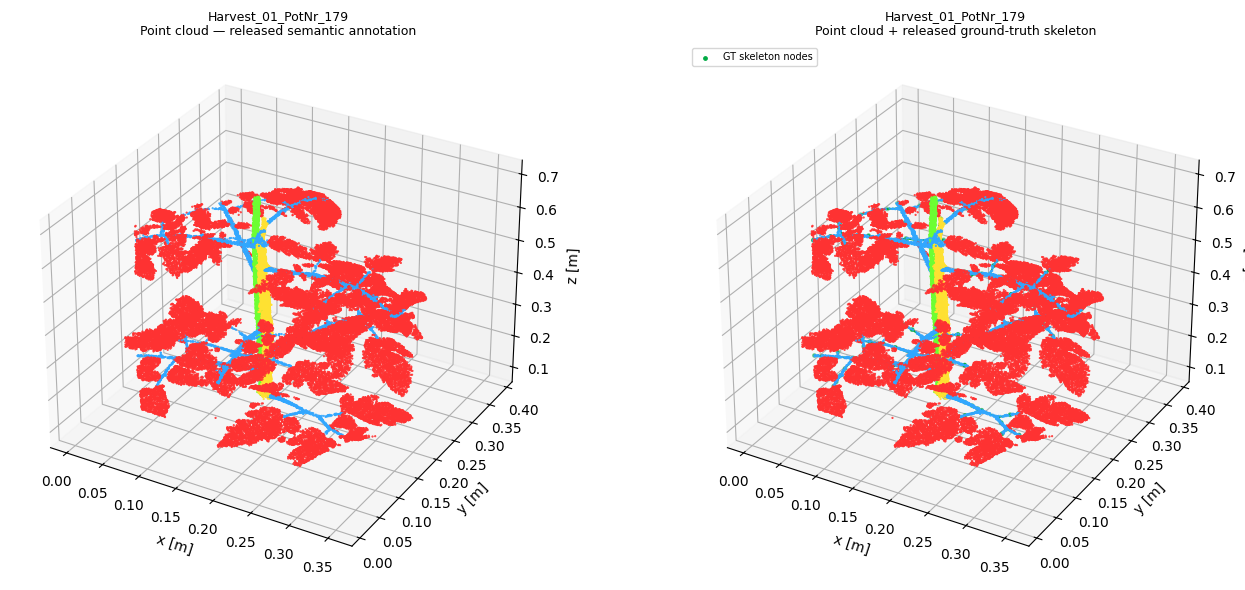

points: 254402 | GT nodes: 185 | GT edges: 184


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scripts.utils_data import create_skeleton_gt_data

SEM_COLORS = {0: "#aaaaaa", 1: "#ff3232", 2: "#ffe132", 3: "#6dff32", 4: "#32a7ff", 5: "#a732ff", 255: "#666666"}
SEM_NAMES = {0: "noise/other", 1: "leaves", 2: "main stem", 3: "pole", 4: "side stems", 5: "other", 255: "noise"}

def load_cloud():
    gt = create_skeleton_gt_data(SKEL_CSV, pc_path=PC_CSV, pc_semantic_path=SEM_CSV)
    return gt

S_gt = load_cloud()
xyz = S_gt.get_xyz_pointcloud()
semantic = S_gt.get_semantic_pointcloud().astype(int)

rng = np.random.default_rng(0)
idx = rng.choice(len(xyz), size=min(60000, len(xyz)), replace=False)
sub = xyz[idx]; sub_sem = semantic[idx]
colors = np.array([SEM_COLORS.get(int(s), "#aaaaaa") for s in sub_sem])

skel_nodes = S_gt.get_node_attribute("pos")
skel_edges = S_gt.get_edges()

fig = plt.figure(figsize=(14, 6))
for k, (show_skel, title) in enumerate([(False, "Point cloud — released semantic annotation"),
                                        (True, "Point cloud + released ground-truth skeleton")]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    ax.scatter(sub[:, 0], sub[:, 1], sub[:, 2], s=0.3, c=colors, depthshade=False)
    if show_skel:
        for e in skel_edges:
            ax.plot(*skel_nodes[[e[0], e[1]]].T, color="#00aa44", lw=1.2)
        ax.scatter(*skel_nodes.T, c="#00aa44", s=6, label="GT skeleton nodes")
    ax.set_title(f"{PLANT}\n{title}", fontsize=9)
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
    if show_skel:
        ax.legend(loc="upper left", fontsize=7)
plt.tight_layout(); plt.savefig("/content/input_preview.png", dpi=110); plt.show()
print(f"points: {len(xyz)} | GT nodes: {len(skel_nodes)} | GT edges: {len(skel_edges)}")

## 9. Xu skeletonisation on the filtered point cloud (authors' method)

Following `WurTomatoData.run_skeletonisation` with the tag's `config.yaml`: drop leaves
and pole points, find the root with `findBottomCenterRoot(method="circle_fit")` (as
configured for the paper), then run the bundled PlantScan3D Xu implementation
(`xu_method`, `binratio=20`, `n_neighbors=20`, `np.random.seed(0)` inside) and convert
the MTG to nodes/edges with edge types. The predicted skeleton is saved exactly like
the authors' pipeline (`export_as_nodelist`).

**日本語:** 著者の `run_skeletonisation` と tag の config.yaml に従い、葉と支柱を除いた点群から root を circle_fit で求め、Xu法（binratio=20, n_neighbors=20, 乱数seed固定）で骨格化して node list CSV として保存します。

In [ ]:
import time
from scripts.utils_skeletonisation import findBottomCenterRoot
from skeletonisation_methods.plantscan3d import xu
from scripts.skeleton_graph import SkeletonGraph

pcd = S_gt.get_xyz_pointcloud()
semantic = S_gt.get_semantic_pointcloud()

# author's get_filtered_data: remove leaves (1) and pole (3)
keep = ~(np.bitwise_or(semantic == 1, semantic == 3))
pcd_filtered, semantic_filtered = pcd[keep], semantic[keep]
print("filtered points:", len(pcd_filtered))

root_idx = findBottomCenterRoot(pcd_filtered, semantic_filtered, method="circle_fit")
print("root (circle_fit):", pcd_filtered[root_idx])

t0 = time.time()
positions, parents, mtg = xu.xu_method(pcd_filtered, root_idx=root_idx, binratio=20, nearest_neighbour=20, vis=False)
nodes, edges, edge_type = xu.xu_method_connect_points(positions, parents, mtg)
t_xu = time.time() - t0
print(f"Xu skeletonisation: {len(nodes)} nodes, {len(edges)} edges in {t_xu:.1f} s")

S_pred = SkeletonGraph()
S_pred.load(nodes, edges, edge_types=edge_type, df_pc=pd.DataFrame(pcd, columns=["x", "y", "z"]), name=PLANT)
S_pred.get_node_order()

SAVE_DIR = pathlib.Path("/content/outputs/xu")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
PRED_CSV = SAVE_DIR / f"{PLANT}.csv"
S_pred.export_as_nodelist(PRED_CSV)
print("saved:", PRED_CSV)

filtered points: 36528
root (circle_fit): [0.157 0.187 0.104]
Compute Remanian graph.


Compute distance to root.


Compute cluster according to distance to root.
Nb of groups : 118
Compute adjacency graph of groups.


Compute centroid of groups.
Compute spanning tree of groups.
Remove short nodes  
Xu skeletonisation: 119 nodes, 118 edges in 4.0 s
saved: /content/outputs/xu/Harvest_01_PotNr_179.csv


## 10. Evaluation against the released ground-truth skeleton (authors' metrics)

Using the authors' `Evaluation` class with the tag's post-processing settings:
first a **sanity check** (ground truth vs itself — must give precision = recall = 1),
then predicted vs ground truth. Node matching uses the 2 cm Euclidean threshold with
per-node-order counts (0,1,2,≥3), plus Chamfer distance, edge TP/FP/FN, and trait
errors (MAE/MAPE) for internode length, phyllotactic angle and leaf angle against the
manual-measurement columns of the released skeleton.

**日本語:** 著者の `Evaluation` クラスで評価します。まず GT vs GT のサニティチェック（precision=recall=1になるはず）、次に予測骨格 vs GT。ノード一致閾値2 cm、次数別集計、Chamfer距離、エッジTP/FP/FN、形質のMAE/MAPE。

In [ ]:
import copy
from scripts.evaluate_skeletons import Evaluation
from scripts.calculate_metrics import Metrics

# post-processing settings copied verbatim from the tag's config.yaml
EV_CFG = {
    "json_name": "test",
    "post_processing": {
        "methods": ["f2", "f3", "f1", "f2", "f3", "f4", "f5", "f2"],
        "f1": {"gaussian_smoothing": {"var0": 0.25, "var1": 0.25}},
        "f2": {"filter": {"node_order": 100000, "keep_parents_only": True}},
        "f3": {"get_edge_type": None},
        "f4": {"edge_from_filtered": None},
        "f5": {"line_fitting_3d": None},
    },
}

ev = Evaluation(gt_path_dir=PC_CSV.parent, dt_graph_dir=SAVE_DIR, gt_json=None, cfg=EV_CFG)

S_gt_eval = ev.load_gt_data(SKEL_CSV)

print("=== sanity check: GT vs GT (expect precision=recall=1) ===")
nm, em, tm = ev.evaluate_single(copy.deepcopy(S_gt_eval), copy.deepcopy(S_gt_eval), vis=False)
print("nodes:", {k: v for k, v in nm.items() if k in ("TP", "FP", "FN", "Precision", "Recall")})
print("edges:", em)

print("\n=== prediction vs ground truth ===")
S_pred_eval = ev.load_pred_data(PLANT)
node_metrics, edge_metrics, trait_metrics = ev.evaluate_single(S_gt_eval, S_pred_eval, vis=False)
print("nodes:", {k: v for k, v in node_metrics.items() if k in ("TP", "FP", "FN", "Precision", "Recall", "CD")})

Loading /content/data/TomatoWUR/annotations/Harvest_01_PotNr_179_skeleton.csv
=== sanity check: GT vs GT (expect precision=recall=1) ===
Harvest_01_PotNr_179
x
nodes: {'TP': 76, 'FP': 0, 'FN': 0, 'Precision': 1.0, 'Recall': 1.0}
edges: {'TP_edges': 75, 'FP_edges': 0, 'FN_edges': 0, 'Precision_edges': 1, 'Recall_edges': 1}

=== prediction vs ground truth ===
Applying post processing method:  filter
Applying post processing method:  get_edge_type
Applying post processing method:  gaussian_smoothing
Applying post processing method:  filter
Applying post processing method:  get_edge_type
Applying post processing method:  edge_from_filtered
Applying post processing method:  line_fitting_3d
Applying post processing method:  filter
Harvest_01_PotNr_179
x
nodes: {'TP': 54, 'FP': 21, 'FN': 22, 'Precision': 0.72, 'Recall': 0.7105263157894737, 'CD': np.float64(0.023024963232191616)}


## 11. Trait errors and per-order node metrics (tables + CSV export)

We tabulate the returned metrics: node precision/recall per node order, edge metrics,
and per-trait MAE/MAPE over matched true-positive nodes (traits come from the manual
measurements stored in the released skeleton). A CSV copy is saved next to the outputs.

**日本語:** 次数別ノード適合率/再現率、エッジ指標、形質ごとのMAE/MAPE（一致したTPノード上、GT骨格の手動計測値と比較）を表にしてCSV保存します。

In [ ]:
rows = []
for order_str in [""] + ["_" + str(x) for x in [0, 1, 2, 3]]:
    tp = node_metrics.get("TP" + order_str); fp = node_metrics.get("FP" + order_str); fn = node_metrics.get("FN" + order_str)
    if tp is None:
        continue
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    rows.append({"node_order": order_str or "all", "TP": int(tp), "FP": int(fp), "FN": int(fn), "Precision": round(prec, 3), "Recall": round(rec, 3)})
df_nodes = pd.DataFrame(rows)
display(df_nodes)

edge_row = pd.DataFrame([{k: edge_metrics[k] for k in ("TP_edges", "FP_edges", "FN_edges")}])
edge_row["Precision_edges"] = edge_metrics["Precision_edges"]
edge_row["Recall_edges"] = edge_metrics["Recall_edges"]
display(edge_row)

trait_rows = []
for trait, vals in trait_metrics.items():
    if vals["gt"]:
        m = Metrics(y_pred=vals["dt"], gt=vals["gt"]).return_dataframe()
        trait_rows.append({"trait": trait, "N_matched": vals["counter"], "N_notmatched": vals["counter_notmatched"],
                           "MAE": m["MAE"][0], "MAPE[%]": m["MAPE"][0]})
    else:
        trait_rows.append({"trait": trait, "N_matched": vals["counter"], "N_notmatched": vals["counter_notmatched"], "MAE": None, "MAPE[%]": None})
df_traits = pd.DataFrame(trait_rows)
display(df_traits)

out_csv = SAVE_DIR / f"metrics_{PLANT}.csv"
df_nodes.to_csv(out_csv, index=False)
edge_row.to_csv(SAVE_DIR / f"metrics_edges_{PLANT}.csv", index=False)
df_traits.to_csv(SAVE_DIR / f"metrics_traits_{PLANT}.csv", index=False)
print("saved:", out_csv)

,node_order,TP,FP,FN,Precision,Recall
0,all,54,21,22,0.720,0.711
1,_0,6,3,5,0.667,0.545
2,_1,23,7,8,0.767,0.742
3,_2,24,8,10,0.750,0.706
4,_3,0,4,0,0.000,0.000


,TP_edges,FP_edges,FN_edges,Precision_edges,Recall_edges
0,39,35,36,0,0


N = 1
Mean Error -0.01 std 0.00
Mean Absolute Error 0.01 std 0.00
Mean Squared Error 0.00 std 0.00
Root Mean Squared Error 0.01 std nan
Mean Absolute Percentage Error 25.23[percentage] std 0.00
N = 1
Mean Error 10.75 std 0.00
Mean Absolute Error 10.75 std 0.00
Mean Squared Error 115.52 std 0.00
Root Mean Squared Error 10.75 std nan
Mean Absolute Percentage Error 3.71[percentage] std 0.00


,trait,N_matched,N_notmatched,MAE,MAPE[%]
0,gt_int_length,1,7,0.012616,25.232988
1,gt_ph_angle,1,7,10.747962,3.706194
2,gt_lf_angle,0,8,NaN,NaN


saved: /content/outputs/xu/metrics_Harvest_01_PotNr_179.csv


## 12. Predicted skeleton vs ground-truth skeleton (visual comparison)

Same rendering convention as the preview: released ground-truth skeleton in **green**,
Xu prediction (after the authors' post-processing) in **red**, point cloud subsample in
grey. Differences in node counts, missing branches and Chamfer distance (reported above)
should be visible.

**日本語:** 緑＝公開GT骨格、赤＝Xu予測（著者の後処理適用後）、灰色＝点群サブサンプルの比較図です。

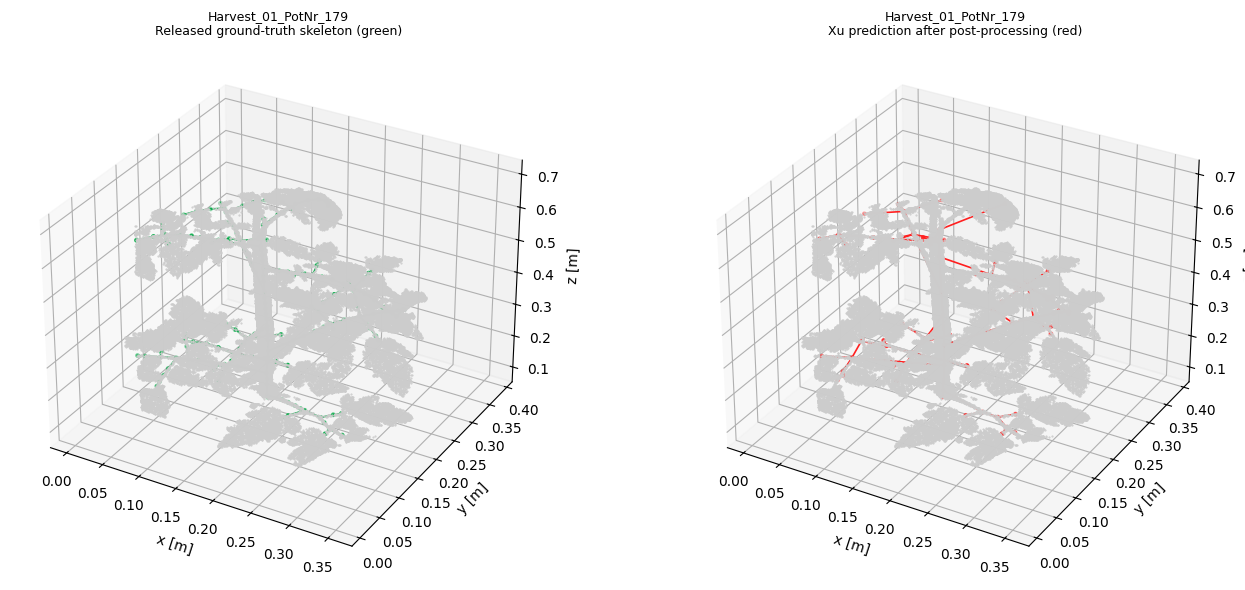

GT nodes: 185 | predicted nodes: 75


In [ ]:
pred_nodes = S_pred_eval.get_node_attribute("pos")
pred_edges = S_pred_eval.get_edges()

fig = plt.figure(figsize=(14, 6))
for k, (nodes_c, edges_c, col, title) in enumerate([
        (skel_nodes, skel_edges, "#00aa44", "Released ground-truth skeleton (green)"),
        (pred_nodes, pred_edges, "#ff2020", "Xu prediction after post-processing (red)")]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    ax.scatter(sub[:, 0], sub[:, 1], sub[:, 2], s=0.3, c="#cccccc", depthshade=False)
    for e in edges_c:
        ax.plot(*nodes_c[[e[0], e[1]]].T, color=col, lw=1.2)
    ax.scatter(*nodes_c.T, color=col, s=6)
    ax.set_title(f"{PLANT}\n{title}", fontsize=9)
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
plt.tight_layout(); plt.savefig("/content/comparison.png", dpi=110); plt.show()
print(f"GT nodes: {len(skel_nodes)} | predicted nodes: {len(pred_nodes)}")

## 13. Interpretation and references

**What this shows:** the released Xu-based skeletonisation pipeline and the released
evaluation methodology run end-to-end on one test plant of the paper's dataset. The
GT-vs-GT sanity check must give perfect node/edge scores; the Xu prediction is scored
against the released ground-truth skeleton with the paper's 2 cm matching threshold,
per-order precision/recall, Chamfer distance, edge TP/FP/FN and trait MAE/MAPE.

**What this does NOT show:** any dataset-level benchmark. The paper is a data paper —
it releases annotations and evaluation software; quantitative comparison across methods
and all 44 plants is outside this minimal demonstration. Node-order 3+ precision is
expected to be low (the paper's own worked example shows this behaviour).

**制限事項 (日本語):** 本ノートブックはデータ論文の公开パイプラインを1株のトマトで実行する最小デモです。44株全体・複数手法の比較は対象外です。

**References**
- van Marrewijk, B.M., van Daalen, T., Smoleňová, K., Xin, B., Polder, G., Kootstra, G. (2025). TomatoWUR: An annotated dataset of tomato plants... *Data in Brief* 61:111852. https://doi.org/10.1016/j.dib.2025.111852
- Code: WUR-ABE/TomatoWUR, tag `original_tomatowur_paper`, commit `8810c57d7d89a7ed78d7dde1c2336ef8748ceaf0` (GPL-3.0).
- Data: 4TU.ResearchData, DOI `10.4121/e2c59841-4653-45de-a75e-4994b2766a2f`, version 2 (CC BY-SA 4.0).